beta_1: 0.0975
beta_2: 0.6525
p_correct_1: 0.87
p_correct_2: 0.13
p_fluke_1: 0.0325
p_fluke_2: 0.2175



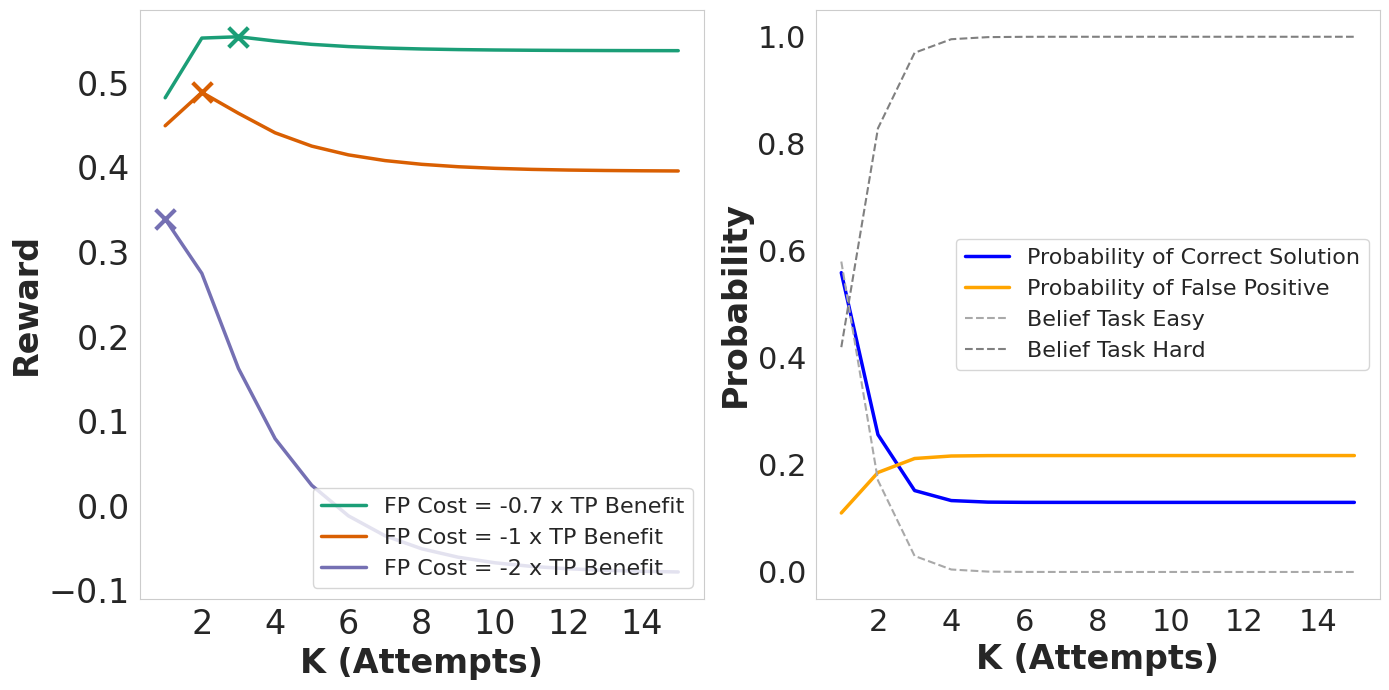

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

r_1 = 0.87 # probability to generate correct solution (easy)
r_2 = 0.13 # (hard)

c = 1 # Completeness (condiitonal probability that verifier accepts a correct solution)
s = 0.75 # Soundness (conditional probability that verifier rejects incorrect solution)

p_1 = 0.58 # prior that task is of type easy
p_2 = 0.42 # prior that task is of type hard

beta_1 = (1 - c) * r_1 + s * (1 - r_1) # true probability that a given attempt will be a reject for easy task
beta_2 = (1 - c) * r_2 + s * (1 - r_2) # for hard task

# Values
V_correct = 1
V_fluke_values = [-0.7, -1, -2]  # Various V_fluke penalty values

# Computational cost (set to 0) (not used)
C_k = 0

p_correct_1 = c * r_1 # probability of a correct accept (easy task)
p_correct_2 = c * r_2 # hard task

p_fluke_1 = (1 - r_1) * (1 - s) # probability of a incorrect accept (easy task)
p_fluke_2 = (1 - r_2) * (1 - s) # hard task

print(
  f"beta_1: {beta_1}\n"
  f"beta_2: {beta_2}\n"
  f"p_correct_1: {p_correct_1}\n"
  f"p_correct_2: {p_correct_2}\n"
  f"p_fluke_1: {p_fluke_1}\n"
  f"p_fluke_2: {p_fluke_2}\n"
)

def get_beliefs(k, beta_1, beta_2, p_1, p_2):
  """
  This compute the conditional probabilities that the given task is of type hard or easy given the number of attempts k.
  Inuition is that as we need more attempt to get a passing solution, the harder task (with lower probability to generate a correct solution) becomes more likely.
  """
  p_t1 = (beta_1**(k-1) * p_1)/(beta_1**(k-1) * p_1 + (beta_2**(k-1)) * p_2)
  p_t2 = (beta_2**(k-1) * p_2)/(beta_1**(k-1) * p_1 + (beta_2**(k-1)) * p_2)
  return p_t1, p_t2

exp_vals_k = []
exp_vals = []
beliefs_T1 = []
beliefs_T2 = []

k_values = range(1, 16)

sns.set_style("whitegrid")
colors = sns.color_palette("Dark2", len(V_fluke_values))

plt.figure(figsize=(14, 7))

# Expected Value for different V_fluke values
plt.subplot(1, 2, 1)

for i, V_fluke in enumerate(V_fluke_values):
    exp_vals = []
    exp_vals_k = []

    for k in k_values:
        p_t1, p_t2 = get_beliefs(k, beta_1, beta_2, p_1, p_2)

        exp_val = (V_correct * (p_correct_1 * p_t1 + p_correct_2 * p_t2) + V_fluke * (p_fluke_1 * p_t1 + p_fluke_2 * p_t2)) * (beta_1**(k-1) * p_t1 + beta_2**(k-1) * p_t2)
        exp_vals_k.append(exp_val)

        exp_vals.append(sum(exp_vals_k[:k]))

    k_opt = k_values[np.argmax(exp_vals)]
    if exp_vals[k_opt-1] < 0:
        k_opt = 0

    plt.plot(k_values, exp_vals, label=f'FP Cost = {V_fluke} x TP Benefit', color=colors[i], linewidth=2.5)

    plt.scatter(k_opt, exp_vals[k_opt-1],
                color=colors[i], s=200, marker='x', linewidth=3)


plt.xlabel('K (Attempts)', fontsize=24, weight='bold')
plt.ylabel('Reward', fontsize=24, weight='bold')
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=16, loc="lower right")
plt.grid()

# Probabilities (for the last V_fluke value, to avoid duplication)
p_correct = []
p_fluke = []
beliefs_T1 = []
beliefs_T2 = []

for k in k_values:
    p_t1, p_t2 = get_beliefs(k, beta_1, beta_2, p_1, p_2)
    p_correct.append(p_correct_1 * p_t1 + p_correct_2 * p_t2)
    p_fluke.append(p_fluke_1 * p_t1 + p_fluke_2 * p_t2)
    beliefs_T1.append(p_t1)
    beliefs_T2.append(p_t2)

# Plot probabilities
plt.subplot(1, 2, 2)
plt.plot(k_values, p_correct, label='Probability of Correct Solution', color='b', linewidth=2.5)
plt.plot(k_values, p_fluke, label='Probability of False Positive', color='orange', linewidth=2.5)
plt.plot(k_values, beliefs_T1, label='Belief Task Easy', color='darkgrey', linestyle='--')
plt.plot(k_values, beliefs_T2, label='Belief Task Hard', color='grey', linestyle='--')
plt.xlabel('K (Attempts)', fontsize=24, weight='bold')
plt.ylabel('Probability', fontsize=24, weight='bold')
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=16)
plt.grid()

plt.tight_layout()
plt.show()